<a href="https://colab.research.google.com/github/isuru963/SHAP---XGBoost-Phishing-URL-Detection-Tool/blob/main/4)_Final_Model_(XGBoost_%2B_SHAP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost shap --quiet

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/top30_features_dataset.csv")
df.head()

,url,google_index,dns_record,nb_www,page_rank,http_in_path,brand_in_path,nb_qm,nb_hyperlinks,phish_hints,...,ratio_intHyperlinks,domain_with_copyright,nb_space,nb_slash,safe_anchor,nb_and,nb_underscore,domain_age,domain_in_title,status
0,http://www.crestonwood.com/router.php,1,1,1,4,0,0,0,17,0,...,0.529412,1,0,3,0.0,0,0,-1,0,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,1,0,0,2,0,0,0,30,0,...,0.966667,0,0,5,100.0,0,0,5767,1,phishing
2,https://support-appleld.com.secureupdate.duila...,1,0,0,0,0,0,1,4,0,...,1.000000,0,0,5,100.0,2,2,4004,1,phishing
3,http://rgipt.ac.in,0,0,0,3,0,0,0,149,0,...,0.973154,0,0,2,62.5,0,0,-1,1,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,0,0,1,6,0,0,0,102,0,...,0.470588,1,0,5,0.0,0,0,8175,0,legitimate


In [ ]:
df["status"] = df["status"].map({"legitimate": 0, "phishing": 1})

X = df.drop(columns=["url", "status"])
y = df["status"]

print("Number of features:", X.shape[1])


Number of features: 30


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9654
F1 Score: 0.9656

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1143
           1       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



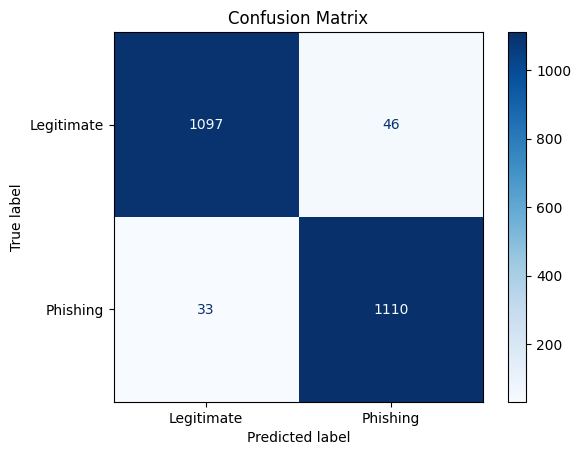

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC–AUC Score: 0.9928


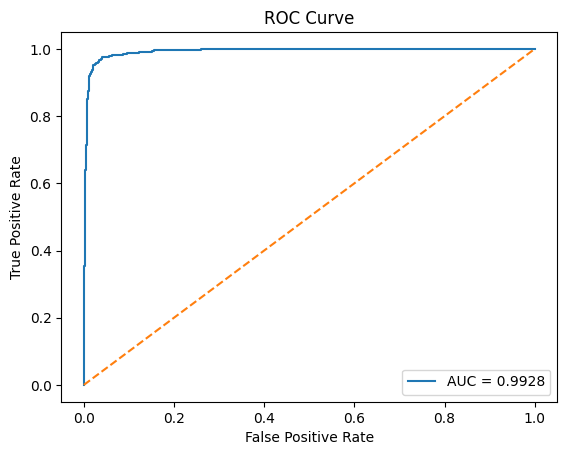

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Prediction probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("ROC–AUC Score:", round(auc_score, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

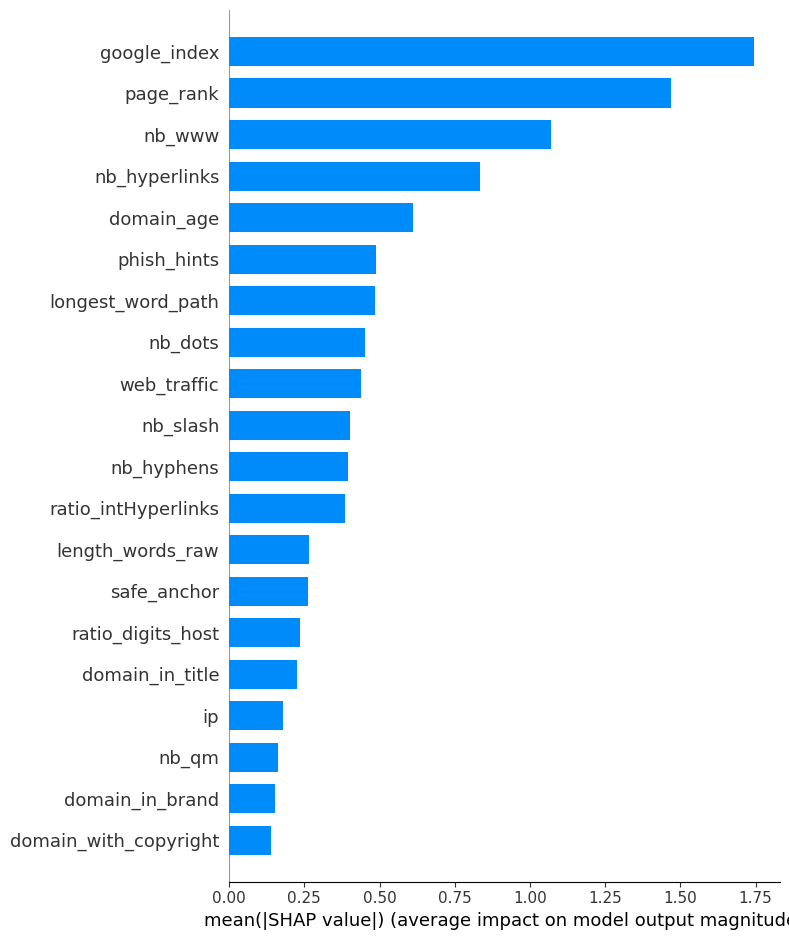

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

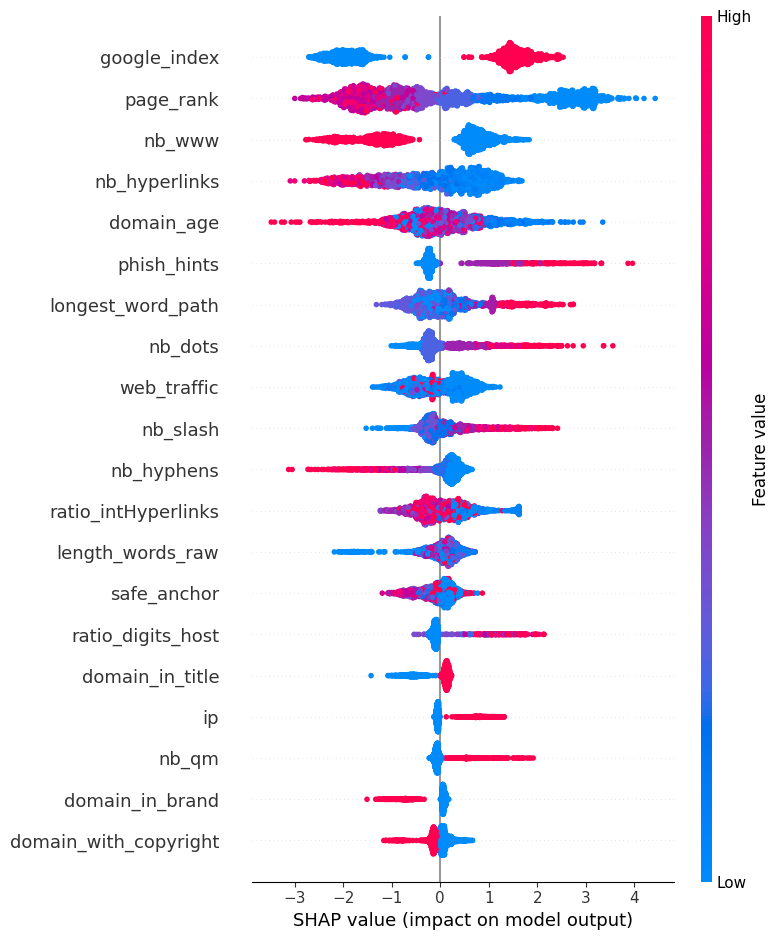

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap_importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Importance": shap_importance
}).sort_values(by="SHAP_Importance", ascending=False)

feature_importance.head(15)

,Feature,SHAP_Importance
0,google_index,1.744159
3,page_rank,1.469600
2,nb_www,1.070318
7,nb_hyperlinks,0.833768
28,domain_age,0.612539
8,phish_hints,0.489305
15,longest_word_path,0.483392
18,nb_dots,0.453021
16,web_traffic,0.439328
24,nb_slash,0.401685


In [ ]:
feature_descriptions = {
    "google_index": "the website is not indexed by Google",
    "page_rank": "the website has a very low page rank",
    "nb_www": "the URL contains multiple 'www' tokens",
    "nb_hyperlinks": "the webpage contains an unusually high number of hyperlinks",
    "phish_hints": "the URL contains phishing-related keywords",
    "domain_age": "the domain is very new or recently registered",
    "web_traffic": "the website has very low web traffic",
    "nb_hyphens": "the URL contains many hyphens",
    "nb_slash": "the URL contains an excessive number of slashes",
    "length_hostname": "the hostname length is unusually long",
    "nb_dots": "the URL contains a high number of dots",
    "longest_word_path": "the URL path contains an unusually long word",
    "ratio_digits_url": "the URL contains a high ratio of digits",
    "ratio_extHyperlinks": "the page contains many external hyperlinks",
    "safe_anchor": "the webpage uses unsafe anchor text links",
    "domain_in_title": "the domain name does not appear in the page title",
    "length_url": "the overall URL length is unusually long",
    "https_token": "the URL misuses the HTTPS token",
    "ratio_digits_host": "the hostname contains many numeric characters",
    "links_in_tags": "suspicious links are embedded inside HTML tags"
}

In [ ]:
def explain_prediction_smart(index, top_k=3):
    # Get the raw values for this specific URL
    row_values = X_test.iloc[index]

    # Get prediction
    pred = xgb_model.predict(X_test.iloc[[index]])[0]
    label = "Phishing" if pred == 1 else "Legitimate"

    # Get SHAP values
    shap_sample = shap_values[index]
    # Get indices of top k features sorted by absolute SHAP impact
    top_indices = np.argsort(np.abs(shap_sample))[-top_k:][::-1]

    reasons = []

    for i in top_indices:
        feature_name = X.columns[i]
        feature_val = row_values[feature_name]
        shap_val = shap_sample[i]

        # --- NOVELTY LOGIC: Context-Aware Descriptions ---

        # 1. Google Index Logic
        if feature_name == "google_index":
            if feature_val == 0: # Assuming 0 = Not Indexed (Bad)
                desc = "the website is NOT indexed by Google"
            else:
                desc = "the website IS verified in Google's index"

        # 2. HTTPS Token Logic
        elif feature_name == "https_token":
            if feature_val == 1: # Assuming 1 = HTTP/Insecure
                desc = "the URL is missing a valid HTTPS certificate"
            else:
                desc = "the URL has a valid security certificate"

        # 3. Domain Age Logic
        elif feature_name == "domain_age":
            if shap_val > 0: # Increasing phishing risk
                desc = "the domain was registered very recently"
            else:
                desc = "the domain has a long-standing history"

        # 4. Length Logic (Generic for all length features)
        elif "length" in feature_name:
            if shap_val > 0:
                desc = f"the {feature_name} is abnormally long"
            else:
                desc = f"the {feature_name} is a normal length"

        # Fallback for other features
        else:
            desc = feature_descriptions.get(feature_name, feature_name)

        # Construct the sentence part
        impact = "raising suspicion" if shap_val > 0 else "indicating safety"
        reasons.append(f"{desc} ({impact})")

    # Final Sentence Construction
    return (
        f"Prediction: {label.upper()}.\n"
        f"Reasoning: {', '.join(reasons)}."
    )

# Test it
print(explain_prediction_smart(index=0))

Prediction: PHISHING.
Reasoning: the website has a very low page rank (raising suspicion), the URL contains phishing-related keywords (raising suspicion), the website IS verified in Google's index (raising suspicion).


In [ ]:
print(explain_prediction(index=0))

This URL is classified as Phishing because the website has a very low page rank which increases the phishing likelihood, and the URL contains phishing-related keywords which increases the phishing likelihood, and the website is not indexed by Google which increases the phishing likelihood.


In [ ]:
results = []

for i in range(len(X_test)):
    results.append({
        "URL": df.loc[X_test.index[i], "url"],
        "Prediction": "Phishing" if xgb_model.predict(X_test.iloc[[i]])[0] == 1 else "Legitimate",
        "Explanation": explain_prediction(i)
    })

explainable_results_df = pd.DataFrame(results)
explainable_results_df.head(10)

,URL,Prediction,Explanation
0,http://nef.com.pk/wp-includes/certificates/red...,Phishing,This URL is classified as Phishing because the...
1,http://www.siliguribaghajatinsportingclub.com/...,Phishing,This URL is classified as Phishing because the...
2,http://assurance-amlfrance.com/id/amelipro/ifr...,Phishing,This URL is classified as Phishing because the...
3,https://diabloiptvreseller.com/payment/,Phishing,This URL is classified as Phishing because the...
4,https://www.supermama.lt/,Legitimate,This URL is classified as Legitimate because t...
5,https://www.drinkaware.co.uk/alcohol-facts/dri...,Legitimate,This URL is classified as Legitimate because t...
6,http://karinscr.tumblr.com,Legitimate,This URL is classified as Legitimate because t...
7,http://https.mercadolivre.com.ttcysuttlart1999...,Phishing,This URL is classified as Phishing because the...
8,https://en.wikipedia.org/wiki/Electronic_keyboard,Legitimate,This URL is classified as Legitimate because t...
9,http://www.clifftopadventure.com/wp-includes/i...,Phishing,This URL is classified as Phishing because the...


In [ ]:
# to download results
"""
explainable_results_df.to_csv("xgboost_shap_explanations.csv", index=False)

from google.colab import files
files.download("xgboost_shap_explanations.csv")
"""

'\nexplainable_results_df.to_csv("xgboost_shap_explanations.csv", index=False)\n\nfrom google.colab import files\nfiles.download("xgboost_shap_explanations.csv")\n'